## ADAML Project (Data Analysis)
### Wind Turbines (A2)
Eetu Knutars, Eetu Peltola, Eero Ryhänen

Importing libraries and setting up the environment

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from seaborn import heatmap
from sklearn.decomposition import PCA
import os

if not os.path.exists('Plots'):
    os.makedirs('Plots')

Data loading with pandas. 

Wind turbine with 31 variables is ignored, since it would be difficult to compare it to other wind turbines since the order of the sensors would not be guaranteed to be correct. Two remaining faulty turbines have 27 variables whereas the healthy turbine has 28 variables, so we remove the last column of the healthy turbine (WT2).

In [55]:
data = {}
sheet_names = ["No.2WT", "No.3", "No.14WT", "No.39WT"]

for sheet in sheet_names:
    df = pd.read_excel("data.xlsx", sheet_name=sheet)

    if df.shape[1] > 28:
        continue
    elif df.shape[1] == 28:
        df = df.iloc[:, :-1]

    # Preprocessing: missing values are handled by interpolation
    nan_locations = df.isna()
    # Print the locations of nan values
    print(f"Nan Locations: {nan_locations[nan_locations].stack().index.tolist()}")
    # Interpolate missing values
    df = df.interpolate(method='linear', limit_direction='both')

    data[sheet] = df

Nan Locations: []
Nan Locations: [(357, 9)]
Nan Locations: []


Functions for visualization

In [56]:
def plot_correlation_matrix(df, sheet_name):
    corr_matrix = df.corr()
    plt.figure(figsize=(10, 8))
    heatmap(corr_matrix, cmap='coolwarm', square=True)
    plt.title(f"Correlation Matrix - {sheet_name}")
    plt.savefig(f"Plots/Correlation_Matrix_{sheet_name}.svg")
    plt.show()
    return

def plot_variable_distributions(df, sheet_name):
    df.hist(bins=15, figsize=(15, 15))
    plt.suptitle(f"Variable Distributions - {sheet_name}")
    plt.savefig(f"Plots/Variable_Distributions_{sheet_name}.svg")
    plt.show()
    return

def plot_timeseries_data(df, sheet_name):
    plt.figure(figsize=(15, 15))
    for i, col in enumerate(df.columns):
        plt.subplot(5, 6, i + 1)
        plt.plot(df[col])
        plt.title(col)
    plt.tight_layout()
    plt.suptitle(f"Timeseries Data - {sheet_name}", y=1.02)
    plt.savefig(f"Plots/Timeseries_Data_{sheet_name}.svg")
    plt.show()
    return

def plot_pca_variance(df, sheet_name):
    pca = PCA()
    pca.fit(df)
    explained_variance = np.cumsum(pca.explained_variance_ratio_)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot cumulative explained variance
    axes[0].plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
    axes[0].set_title(f"PCA Cumulative Explained Variance - {sheet_name}")
    axes[0].set_xlabel('Number of Components')
    axes[0].set_ylabel('Cumulative Explained Variance')
    axes[0].grid(True)

    # Create a biplot
    pca_transformed = pca.transform(df)
    axes[1].scatter(pca_transformed[:, 0], pca_transformed[:, 1], alpha=0.7, label='Data Points', c=pca_transformed[:, 0], cmap='viridis')
    for i, (pc1, pc2) in enumerate(zip(pca.components_[0], pca.components_[1])):
        axes[1].arrow(0, 0, pc1 * max(pca_transformed[:, 0]), pc2 * max(pca_transformed[:, 1]),
                      color='r', alpha=0.5, head_width=0.05, head_length=0.1)
        axes[1].text(pc1 * max(pca_transformed[:, 0]) * 1.1, 
                     pc2 * max(pca_transformed[:, 1]) * 1.1, 
                     df.columns[i], color='k', ha='center', va='center')
    axes[1].set_title(f"PCA Biplot - {sheet_name}")
    axes[1].set_xlabel('Principal Component 1')
    axes[1].set_ylabel('Principal Component 2')
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Plots/PCA_Explained_Variance_and_Biplot_{sheet_name}.svg")
    plt.show()

Function for data normalization (minmax)

In [57]:
def normalize_dataframe(df):
    # Min-Max normalization based on healthy data
    df_norm = (df - df.min()) / (df.max() - df.min())
    # If a column has constant values, set it to 0.5
    df_norm = df_norm.fillna(0.5)
    return df_norm

Calculating and visualizing correlation matrices 

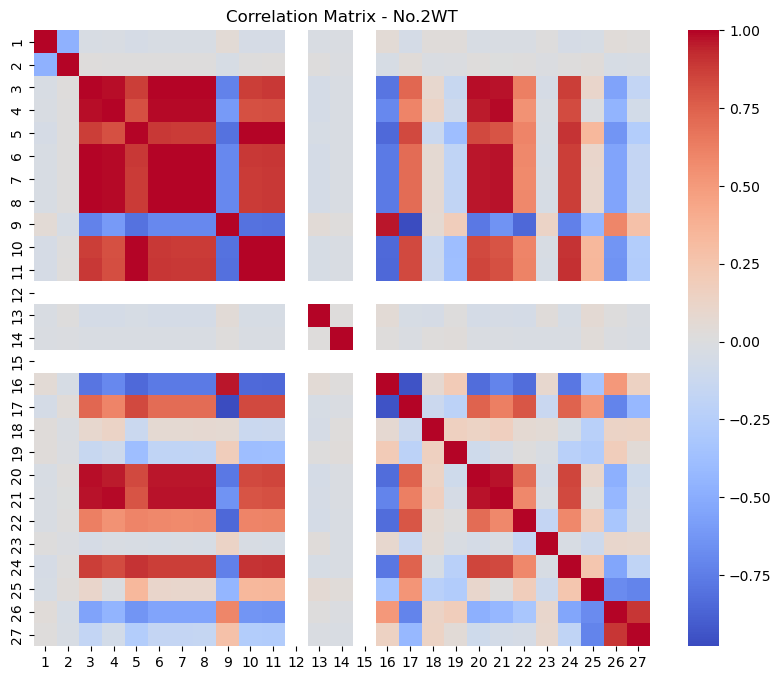

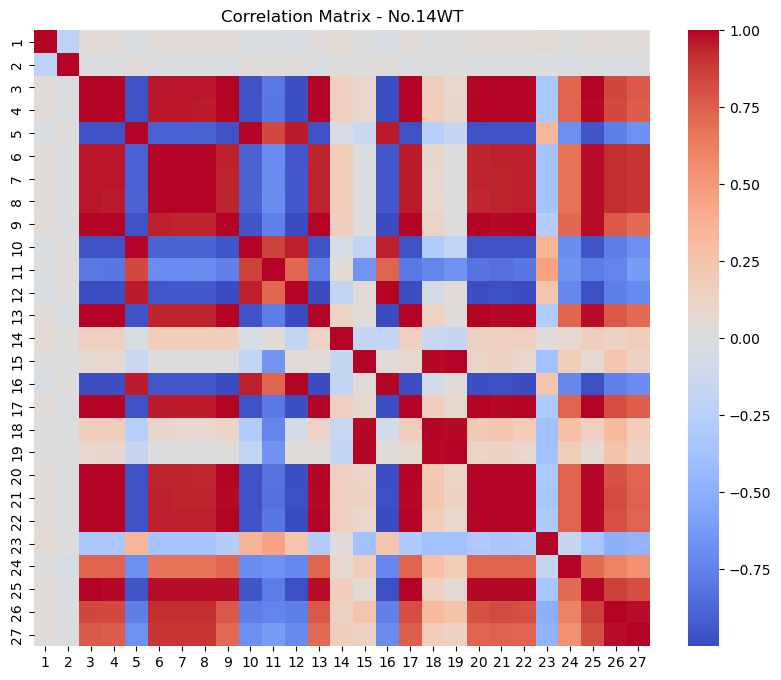

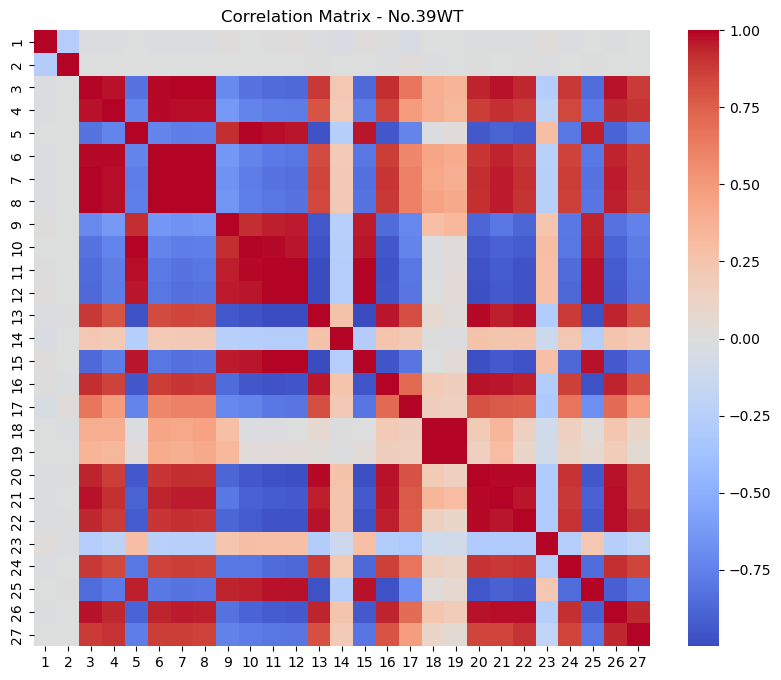

In [58]:
for sheet_name, df in data.items():
    
    # Norm the variables (columns) in the DataFrame
    df_norm = normalize_dataframe(df)
    
    # Plot the correlation matrix
    plot_correlation_matrix(df_norm, sheet_name)

Visualizing the variable distribution of the normalized data

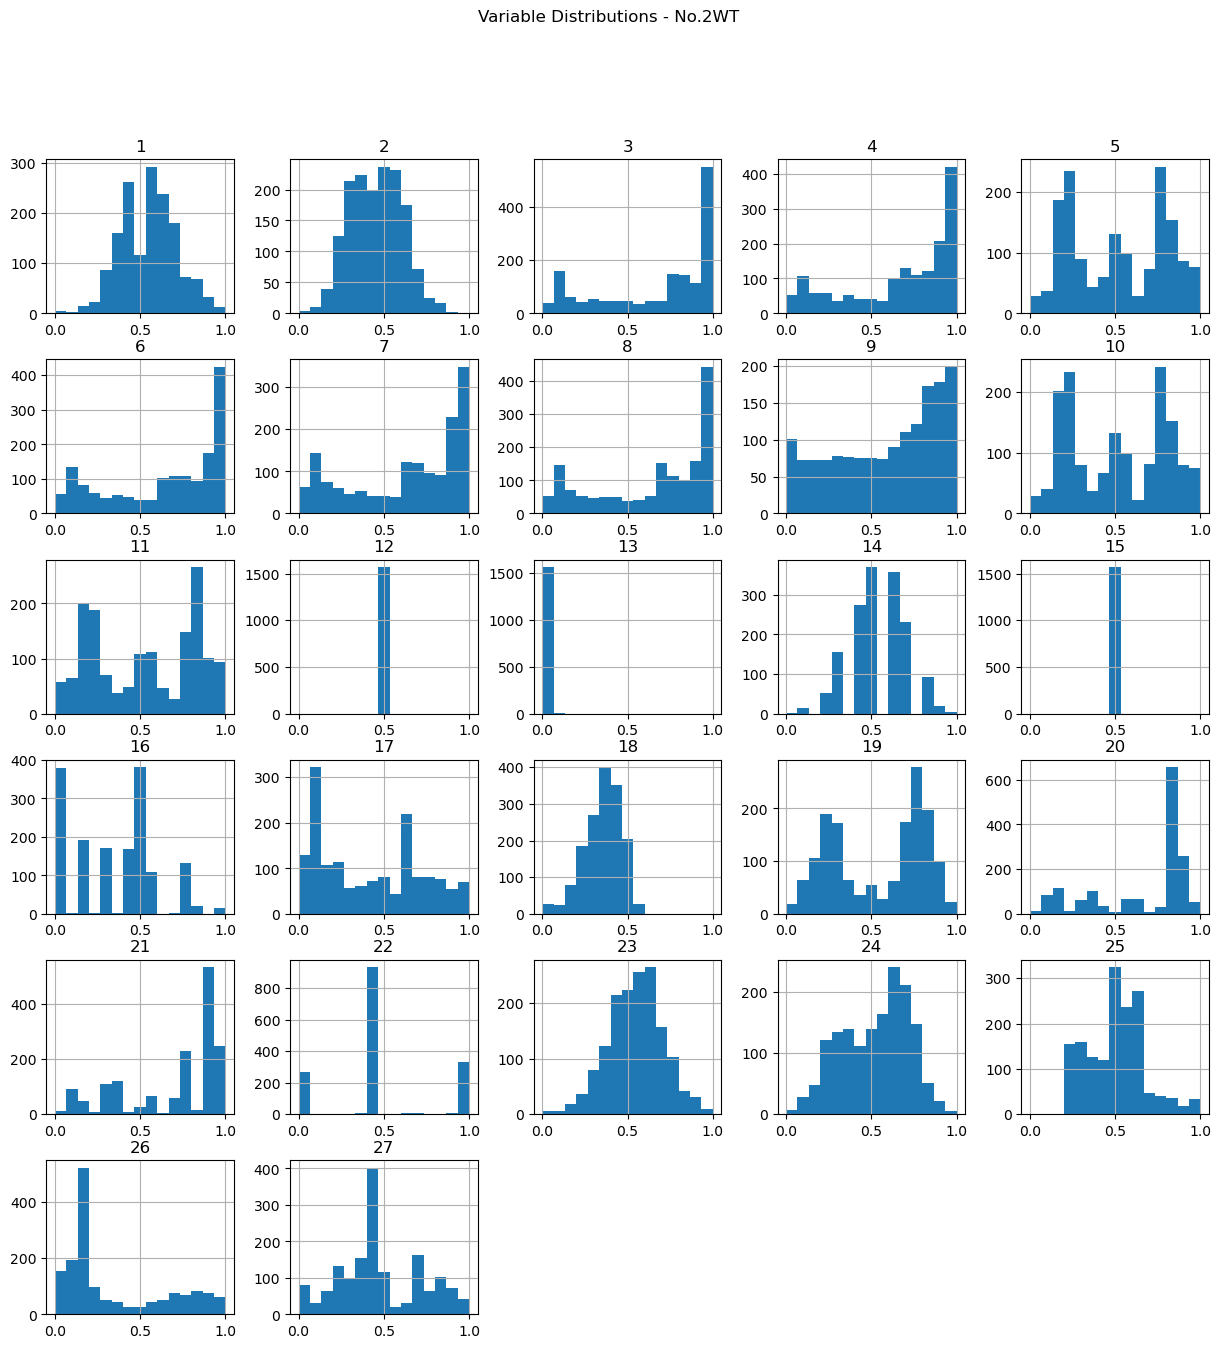

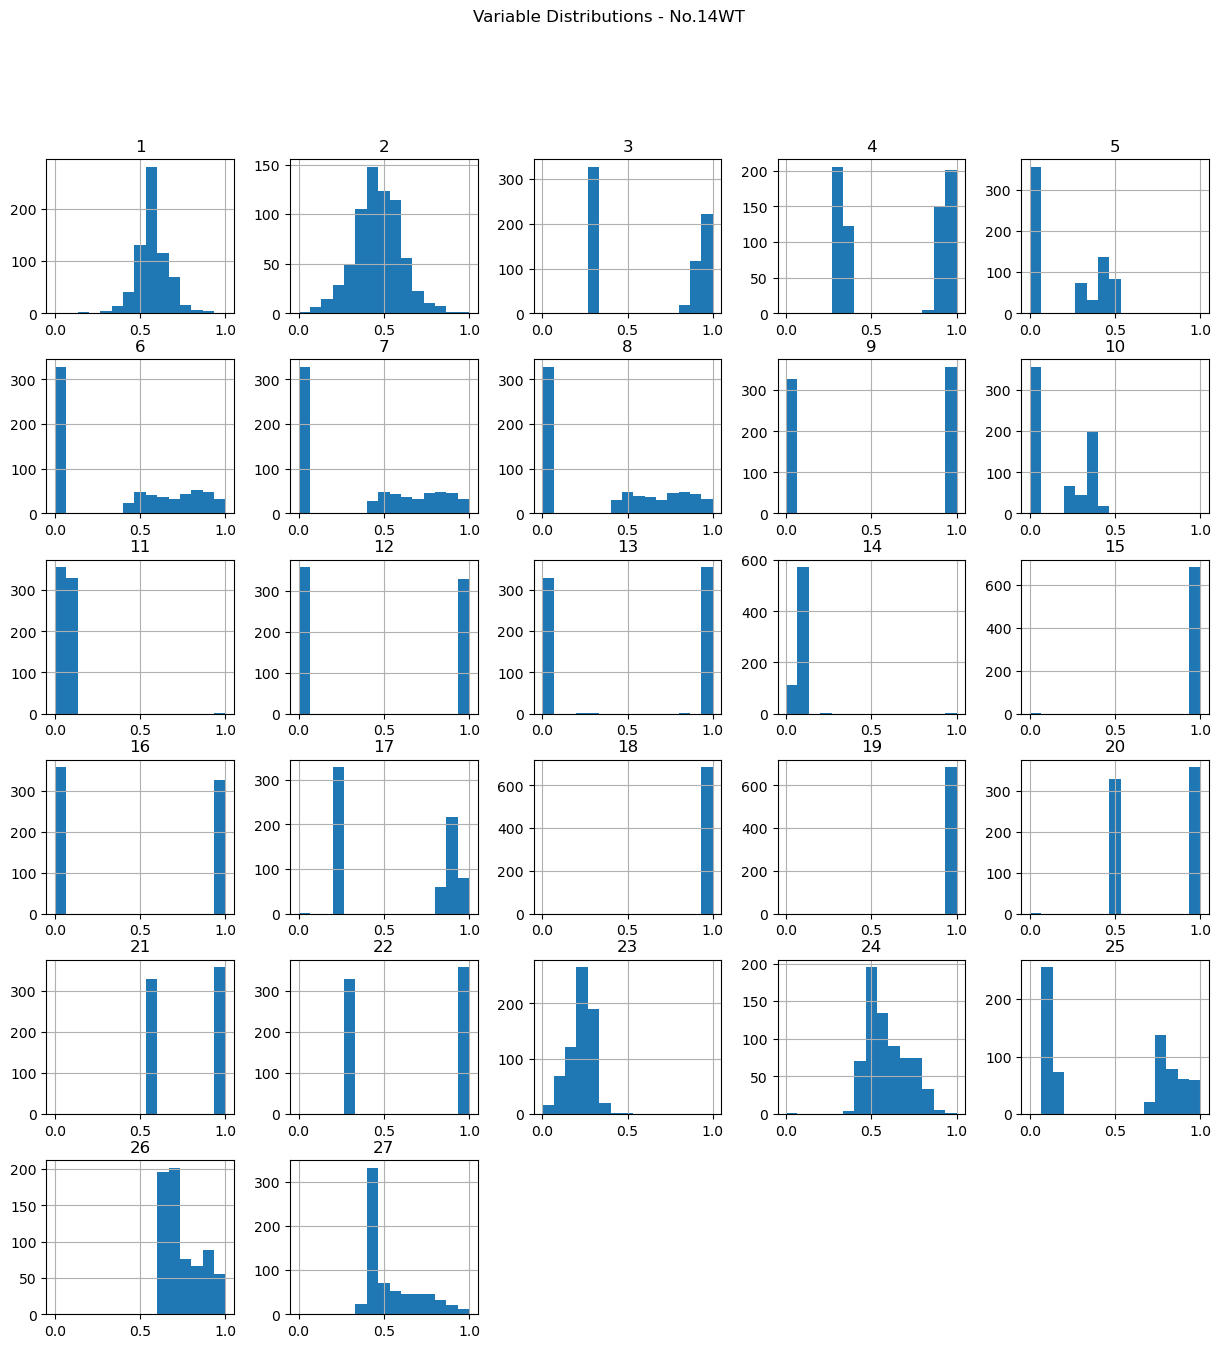

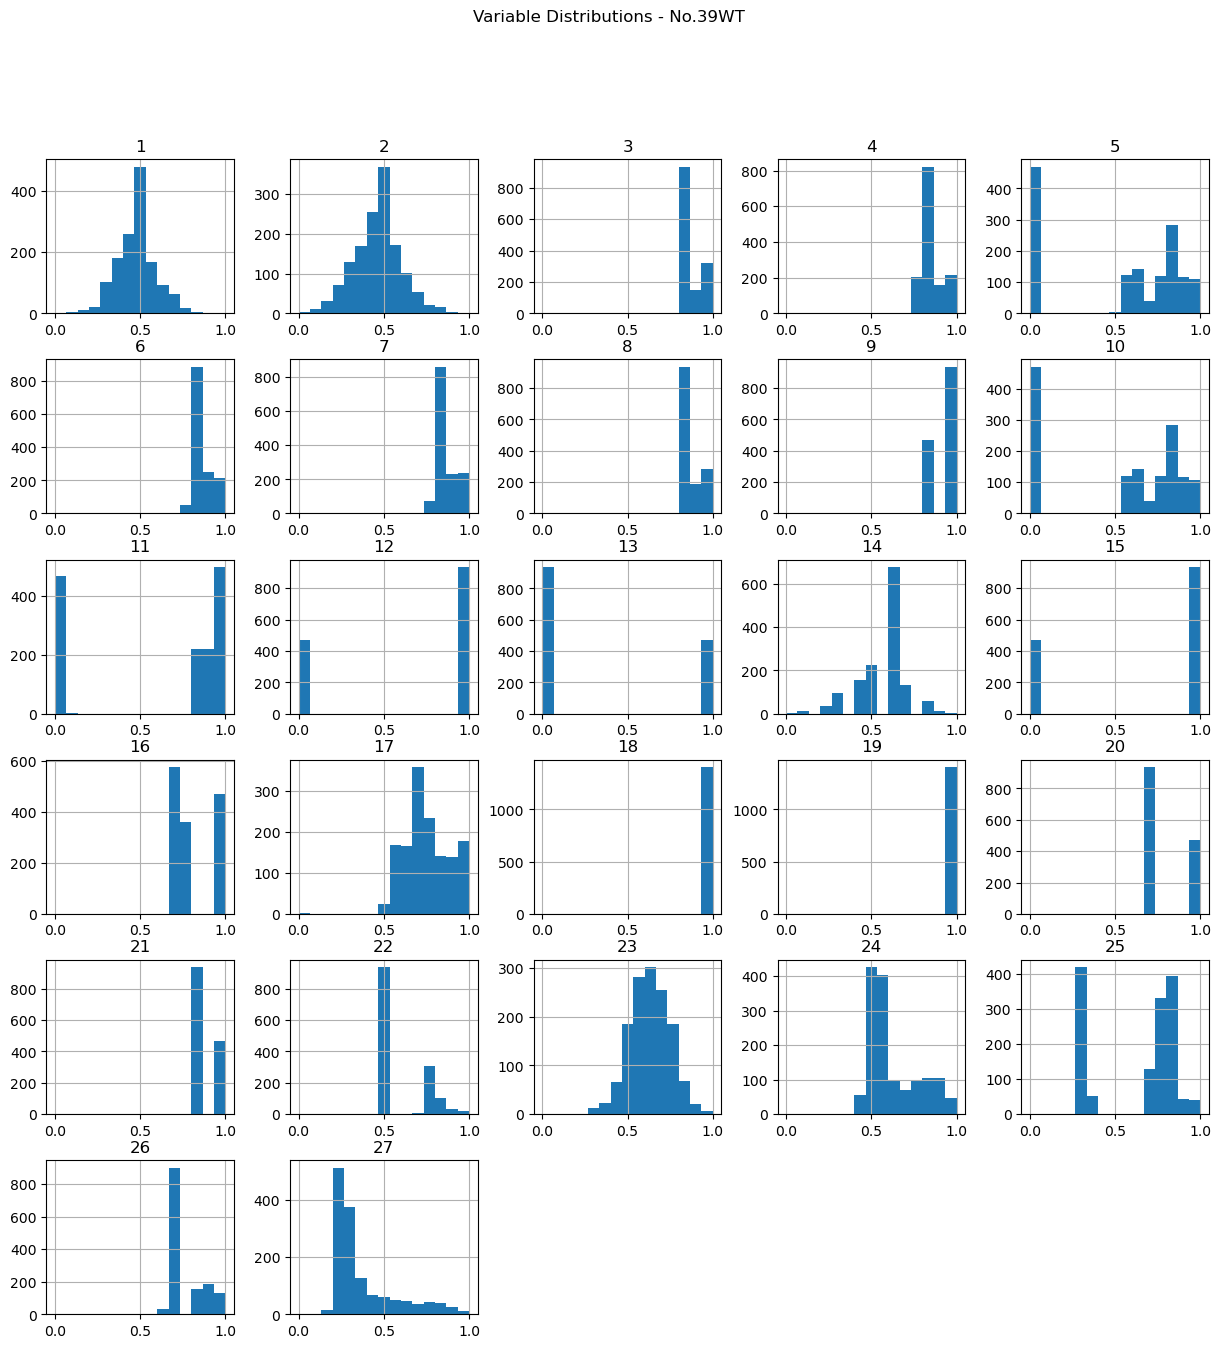

In [59]:
for sheet_name, df in data.items():
    
    # Norm the variables (columns) in the DataFrame
    df_norm = normalize_dataframe(df)

    # Plot variable distributions
    plot_variable_distributions(df_norm, sheet_name)

Visualize the data by plotting all variables as time series. No further data preprocessing is done other than data normalization and handling NaN values.

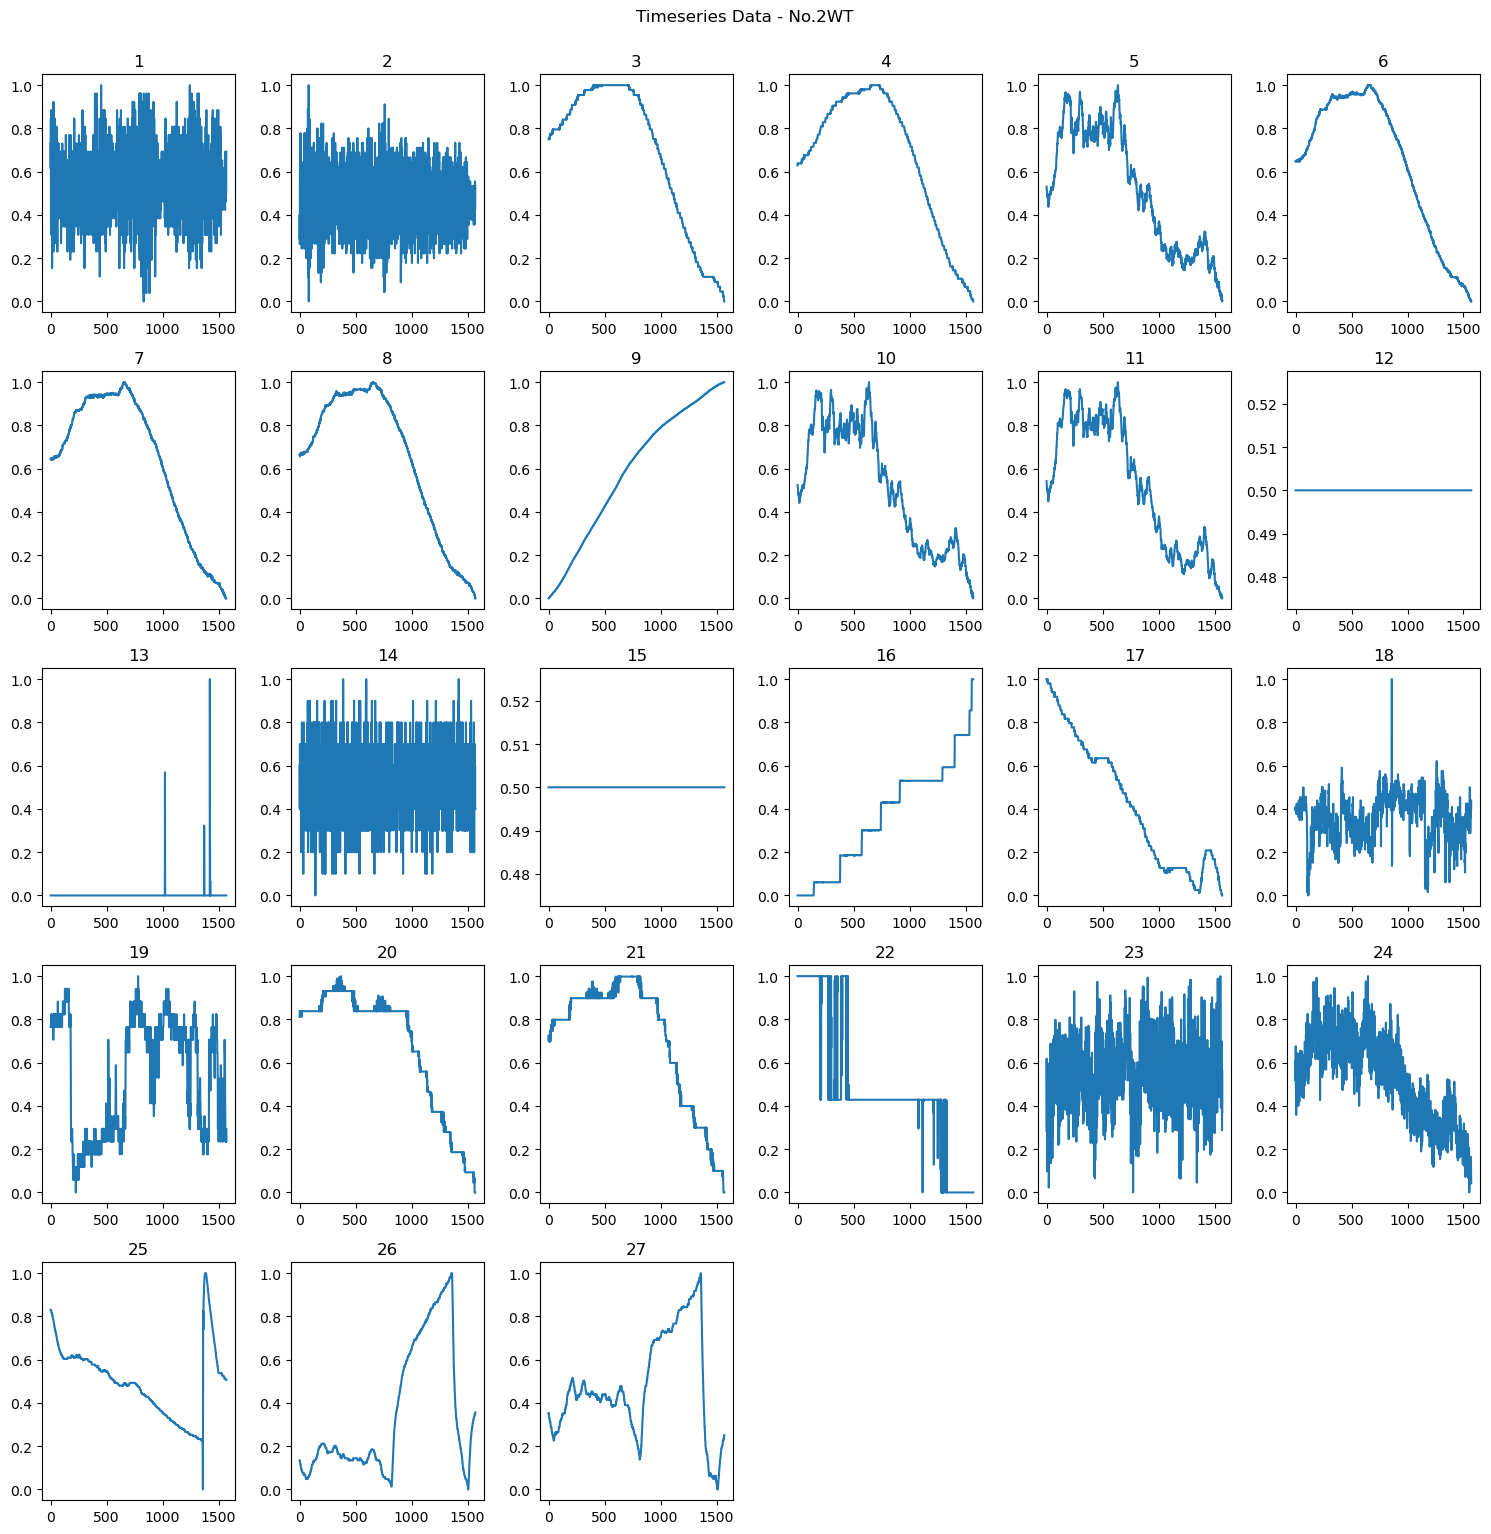

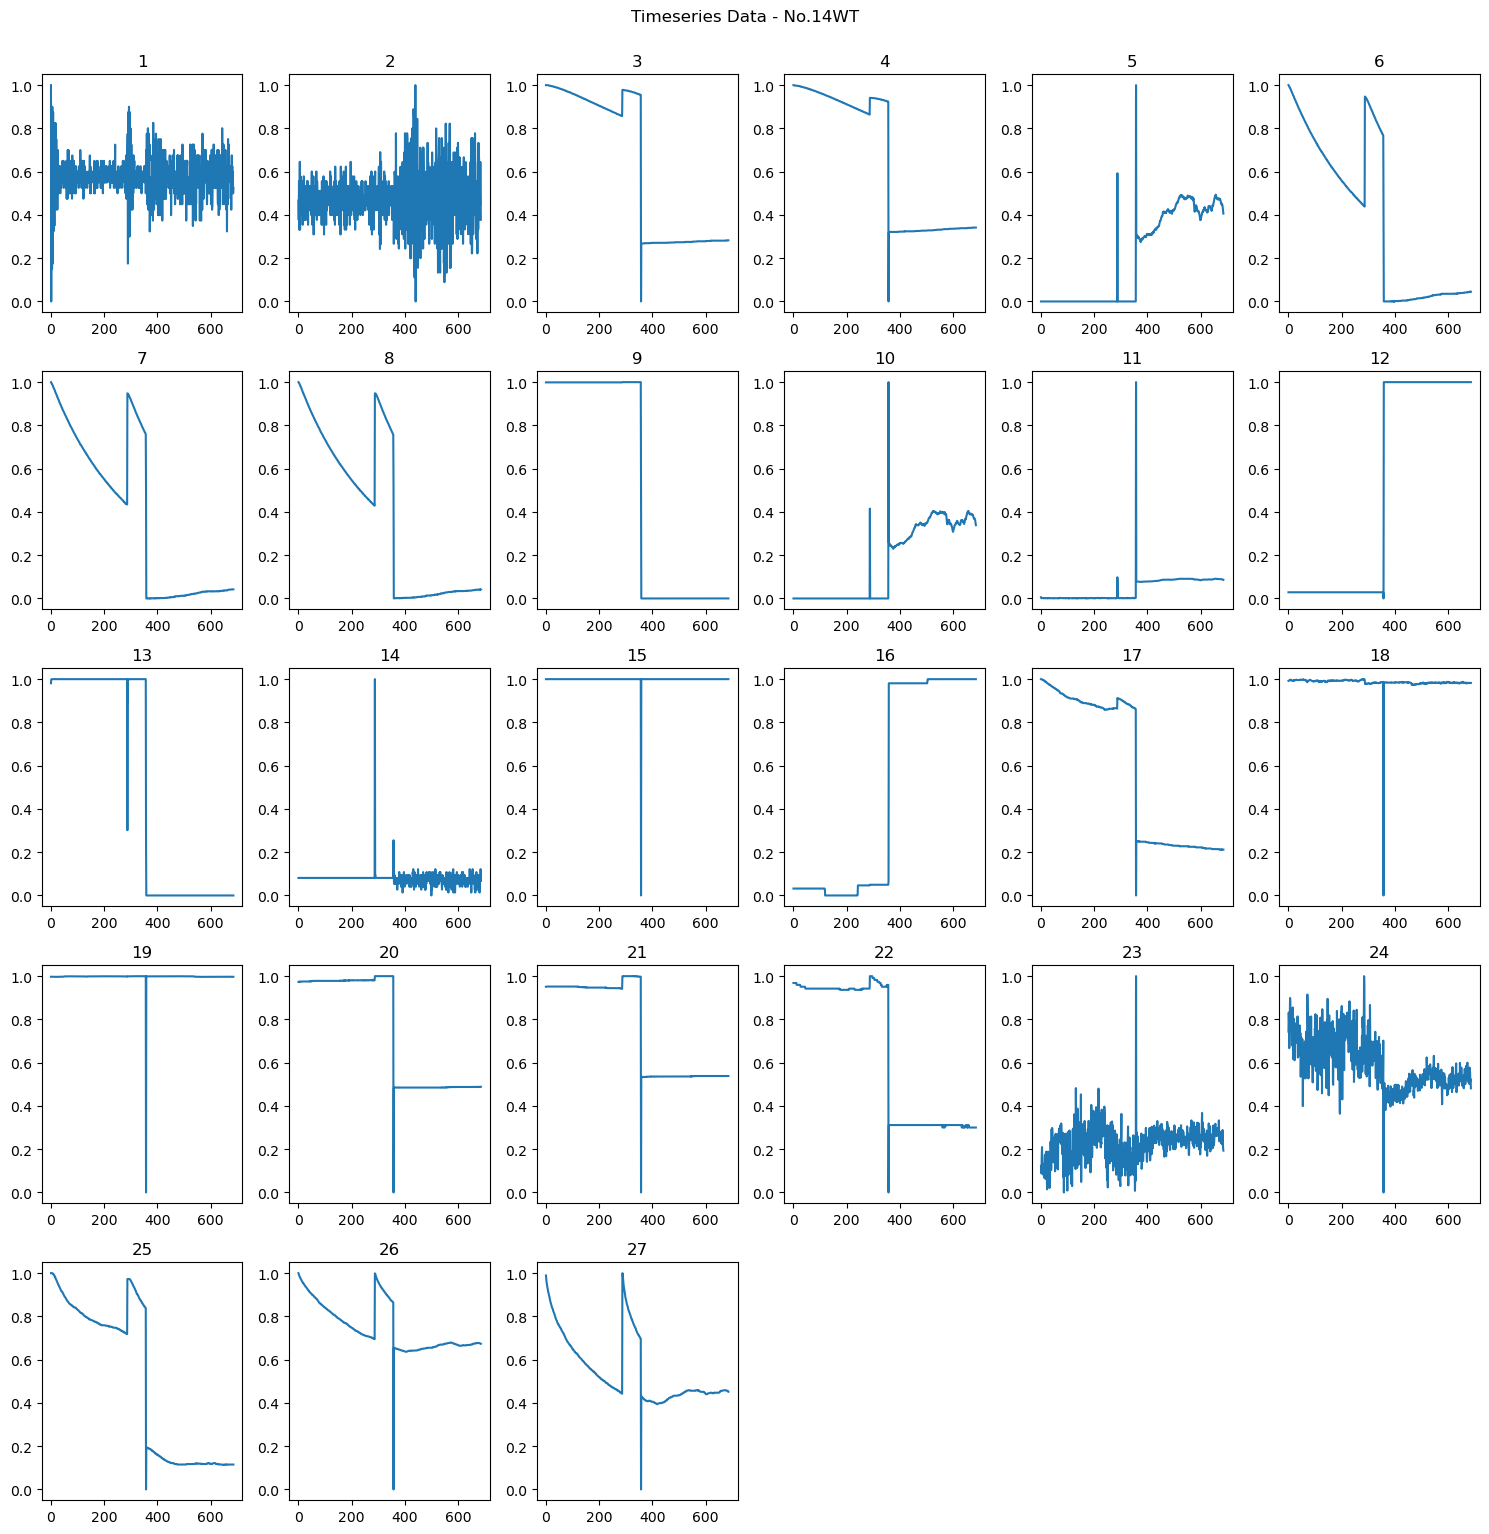

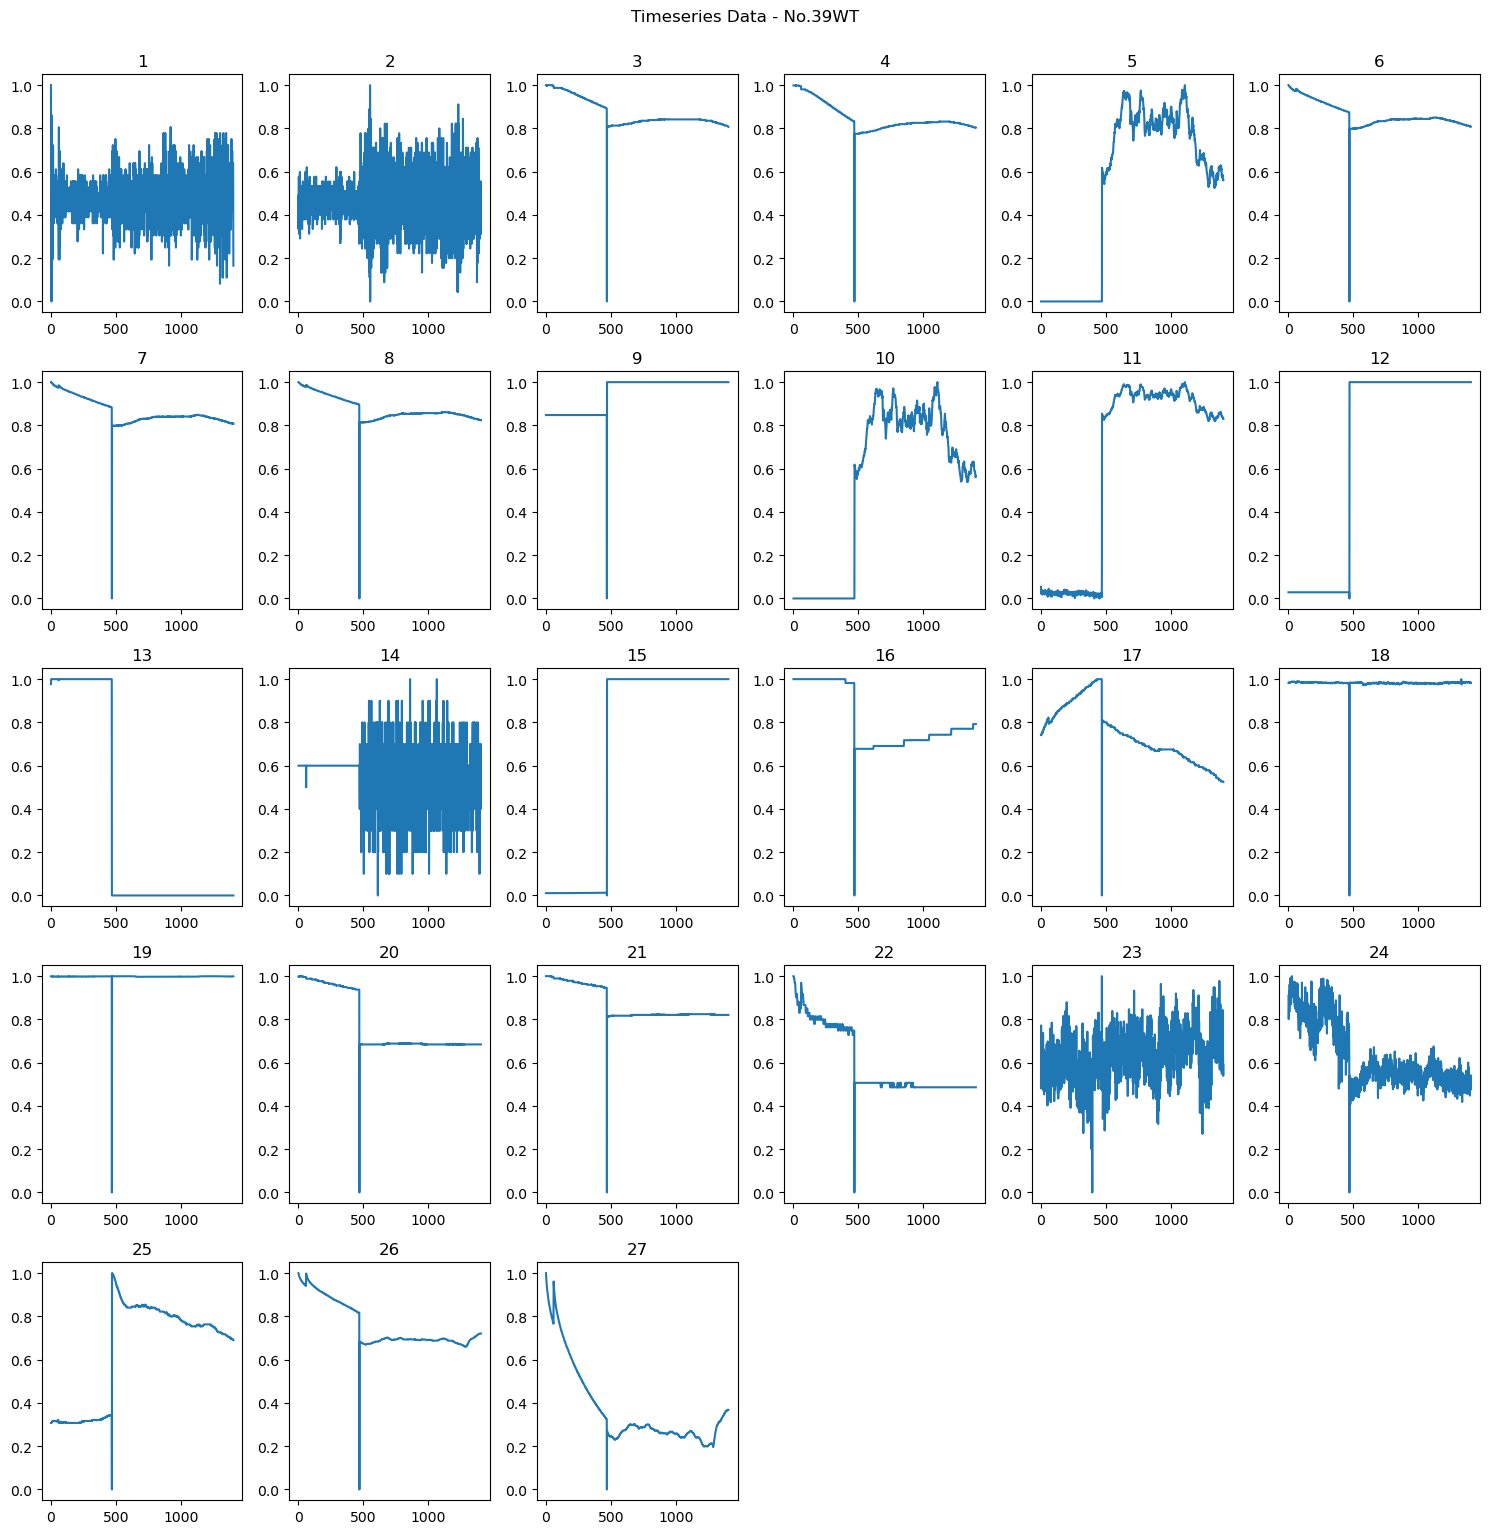

In [60]:
for sheet_name, df in data.items():
    
    # Norm the variables (columns) in the DataFrame
    df_norm = normalize_dataframe(df)
    
    # Plot the timeseries data
    plot_timeseries_data(df_norm, sheet_name)

Calculate and visualize PCA results

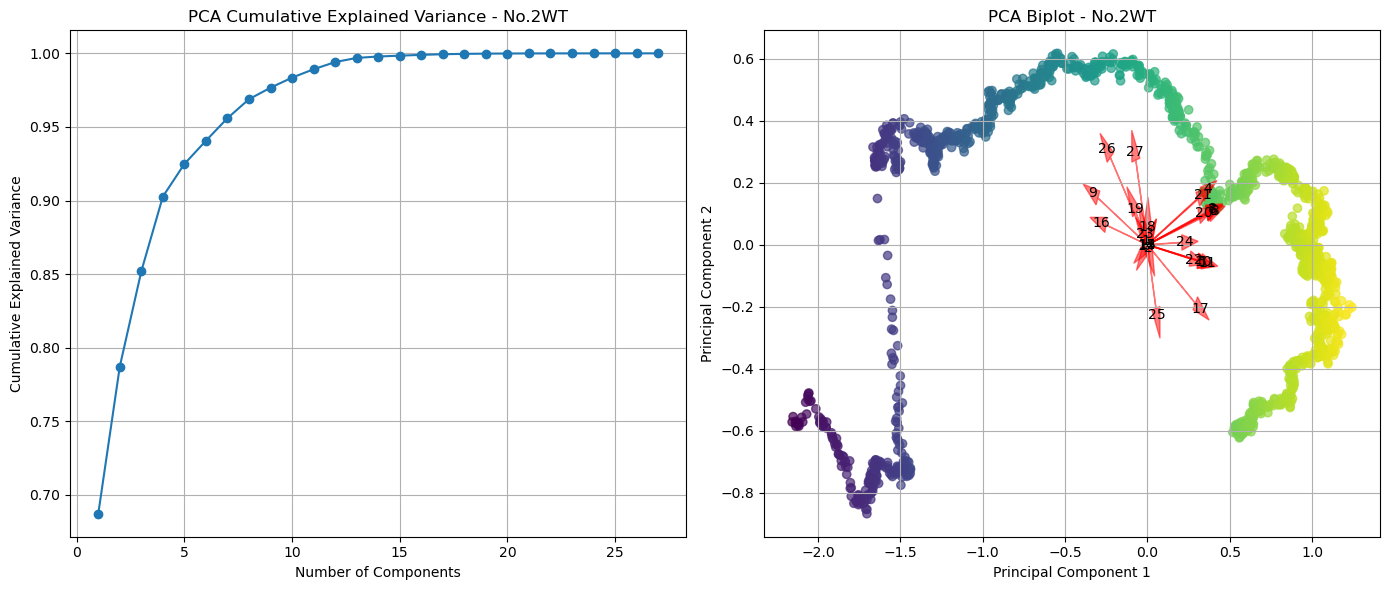

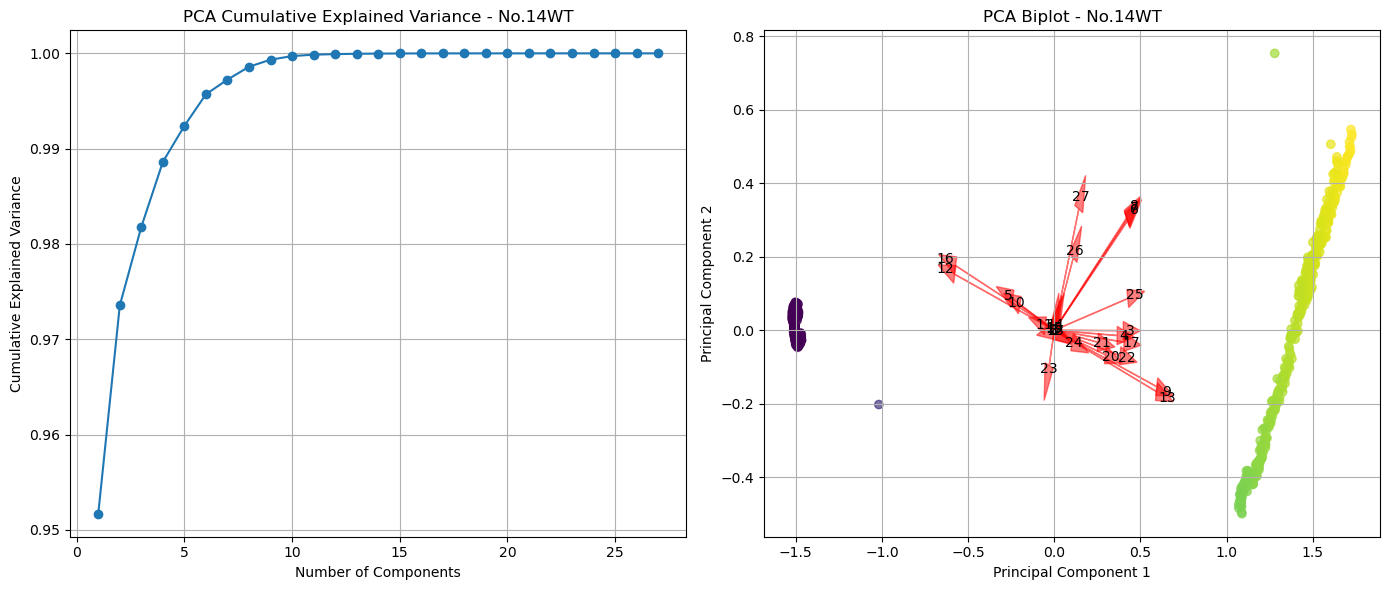

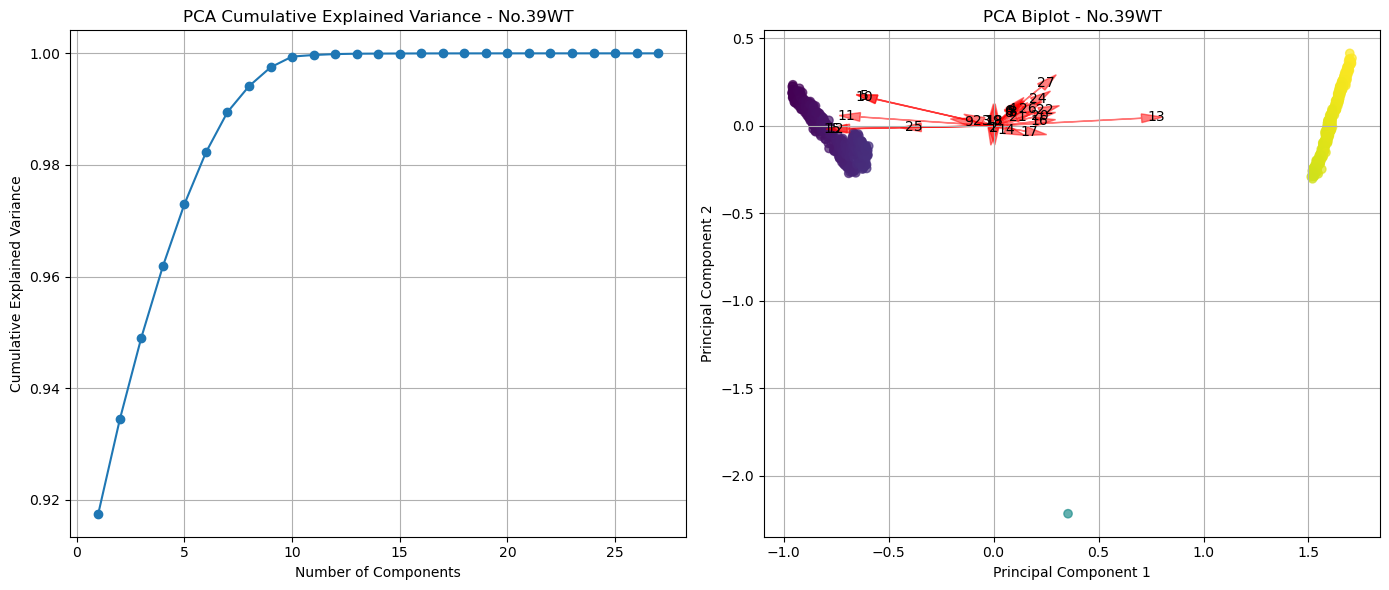

In [61]:
for sheet_name, df in data.items():
    
    # Norm the variables (columns) in the DataFrame
    df_norm = normalize_dataframe(df)
    
    # Plot PCA variance
    plot_pca_variance(df_norm, sheet_name)